In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('StudentPerformance.csv')

In [3]:
df

,Student_id,Math score,Science score,English score,Percentage,Attendence
0,101,71.0,89.0,95.0,85.000000,75.0
1,102,NaN,55.0,50.0,61.333333,NaN
2,103,45.0,83.0,100.0,76.000000,72.0
3,104,86.0,60.0,72.0,67.000000,91.0
4,105,77.0,92.0,51.0,73.333333,99.0
5,106,NaN,56.0,96.0,77.333333,85.0
6,107,54.0,71.0,45.0,56.666667,62.0
7,108,94.0,97.0,56.0,NaN,72.0
8,109,40.0,86.0,85.0,70.333333,77.0
9,110,76.0,64.0,50.0,63.333333,50.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_id     30 non-null     int64  
 1   Math score     27 non-null     float64
 2   Science score  29 non-null     float64
 3   English score  29 non-null     float64
 4   Percentage     28 non-null     float64
 5   Attendence     29 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 1.5 KB


In [5]:
df.describe()

,Student_id,Math score,Science score,English score,Percentage,Attendence
count,30.000000,27.000000,29.000000,29.000000,28.000000,29.000000
mean,115.500000,65.481481,74.344828,70.068966,69.809524,73.068966
std,8.803408,18.768571,16.151682,17.117099,9.851752,16.214920
min,101.000000,40.000000,44.000000,42.000000,51.000000,50.000000
25%,108.250000,46.000000,61.000000,56.000000,63.333333,61.000000
50%,115.500000,70.000000,77.000000,72.000000,69.833333,72.000000
75%,122.750000,83.500000,87.000000,81.000000,77.083333,87.000000
max,130.000000,96.000000,100.000000,100.000000,89.666667,100.000000


In [6]:
df.isnull()

,Student_id,Math score,Science score,English score,Percentage,Attendence
0,False,False,False,False,False,False
1,False,True,False,False,False,True
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,True,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,True,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Student_id       0
Math score       3
Science score    1
English score    1
Percentage       2
Attendence       1
dtype: int64

In [8]:
df['Math score']=df['Math score'].fillna(df['Math score'].mean())

In [9]:
df['Science score']=df['Science score'].fillna(df['Science score'].mean())

In [10]:
df['English score']=df['English score'].fillna(df['English score'].mean())

In [11]:
df['Percentage']=df['Percentage'].fillna(df['Percentage'].mean())

In [12]:
df['Attendence']=df['Attendence'].fillna(df['Attendence'].mean())

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Math score'>

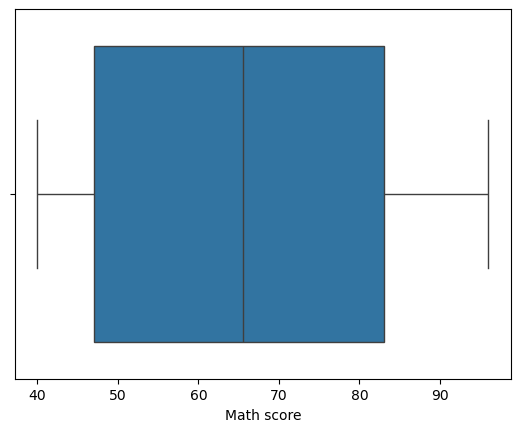

In [14]:
sns.boxplot(x='Math score',data=df) 

<Axes: xlabel='English score'>

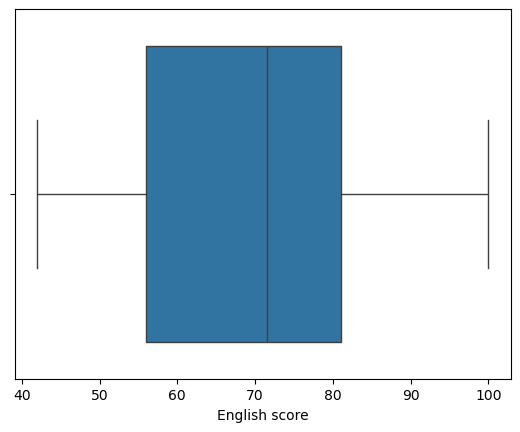

In [38]:
sns.boxplot(x='English score',data=df) 

<Axes: xlabel='Science score'>

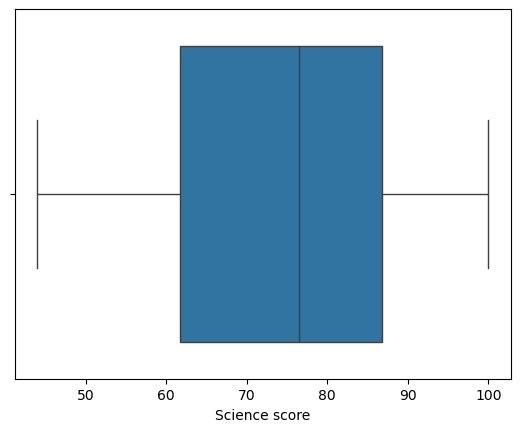

In [40]:
sns.boxplot(x='Science score',data=df) 

<Axes: xlabel='Attendence'>

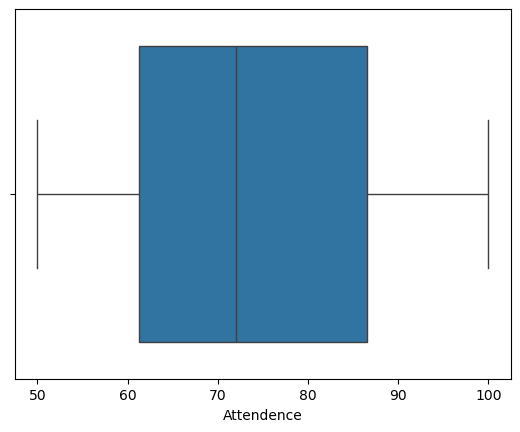

In [42]:
sns.boxplot(x='Attendence',data=df) 

<Axes: xlabel='Percentage'>

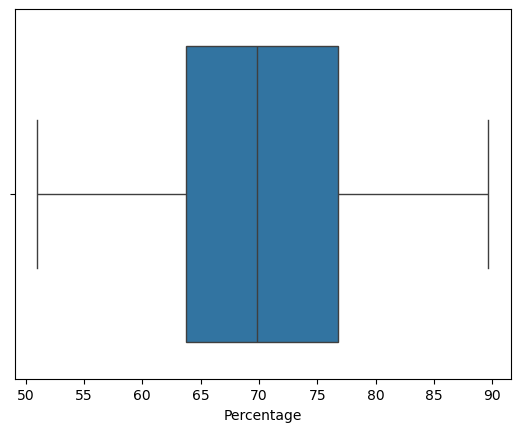

In [44]:
sns.boxplot(x='Percentage',data=df) 

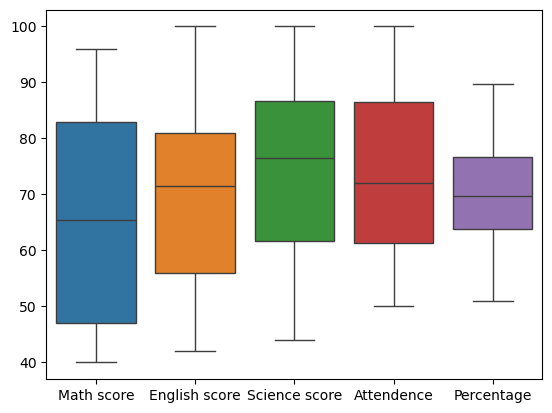

In [15]:
sns.boxplot(data=df[['Math score', 'English score', 'Science score','Attendence','Percentage']])
plt.show()

In [16]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper, upper,
               np.where(df[col] < lower, lower, df[col]))

remove_outliers('Math score')
remove_outliers('Attendence')

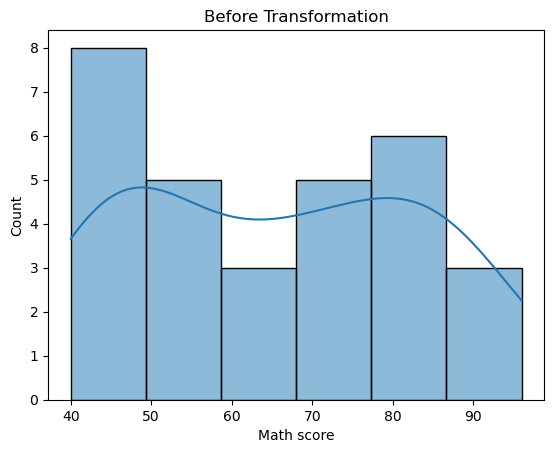

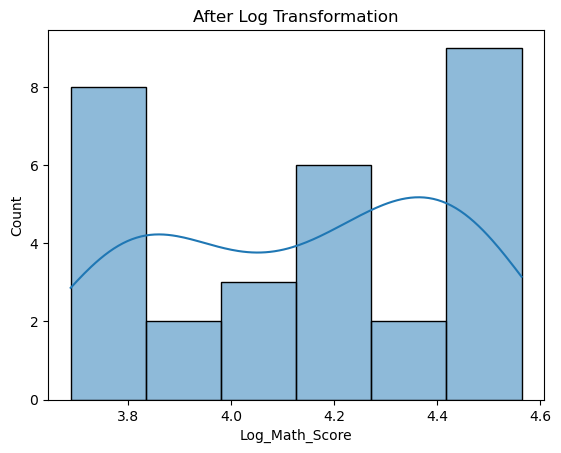

In [17]:
import scipy.stats as stats

# Before transformation
sns.histplot(df['Math score'], kde=True)
plt.title("Before Transformation")
plt.show()

# Apply log transformation
df['Log_Math_Score'] = np.log(df['Math score'])

# After transformation
sns.histplot(df['Log_Math_Score'], kde=True)
plt.title("After Log Transformation")
plt.show()


In [18]:
print(df)

    Student_id  Math score  Science score  English score  Percentage  \
0          101   71.000000      89.000000      95.000000   85.000000   
1          102   65.481481      55.000000      50.000000   61.333333   
2          103   45.000000      83.000000     100.000000   76.000000   
3          104   86.000000      60.000000      72.000000   67.000000   
4          105   77.000000      92.000000      51.000000   73.333333   
5          106   65.481481      56.000000      96.000000   77.333333   
6          107   54.000000      71.000000      45.000000   56.666667   
7          108   94.000000      97.000000      56.000000   69.809524   
8          109   40.000000      86.000000      85.000000   70.333333   
9          110   76.000000      64.000000      50.000000   63.333333   
10         111   58.000000      73.000000      81.000000   69.809524   
11         112   65.481481      64.000000      70.000000   63.333333   
12         113   83.000000      76.000000      42.000000   67.00